In [3]:
import tensorflow as tf
(x_train,y_train),(x_test,y_test)= tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 54s 0us/step


In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
x_test.shape

(10000, 32, 32, 3)

In [9]:
x_train = x_train.reshape(x_train.shape[0],32,32,3)
x_test = x_test.reshape(x_test.shape[0],32,32,3)
input_shape = (32,32,3)

In [10]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [11]:
x_train /= 255 # mandatory step to normalize the pixel of image from 0 -255 to 0-1 range
x_test /= 255

In [12]:
#model creation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

C:\Users\premchandar\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# 2. Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.4705 - loss: 1.4848
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.5818 - loss: 1.1933
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6226 - loss: 1.0717
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6563 - loss: 0.9859
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6776 - loss: 0.9256
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6982 - loss: 0.8691
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.7129 - loss: 0.8316
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7266 - loss: 0.7810
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7385 - loss: 0.7491
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7510 - loss: 0.7138


In [21]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6276 - loss: 1.1251


[1.1251028776168823, 0.6276000142097473]

In [22]:
#predicting the labels_digit
y_predict = model.predict(x_test)
y_predict

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[5.6271872e-04, 3.6646461e-06, 8.9463627e-04, ..., 7.2839612e-06,
        4.1410569e-04, 5.9178128e-05],
       [7.8159720e-03, 7.1475530e-01, 8.0973291e-07, ..., 6.1665389e-08,
        2.7730384e-01, 1.1747002e-04],
       [2.9359579e-01, 1.7050138e-02, 6.6559538e-03, ..., 2.1660392e-04,
        6.7454034e-01, 5.0169164e-03],
       ...,
       [3.8632104e-04, 1.0454196e-06, 8.6967967e-02, ..., 1.5101602e-02,
        9.5239833e-05, 1.4660176e-05],
       [7.6818494e-03, 9.4990498e-01, 6.8752925e-05, ..., 5.2101794e-04,
        4.0665145e-06, 1.0478681e-04],
       [2.0396888e-05, 3.0568819e-05, 1.3326914e-03, ..., 8.7055403e-01,
        2.1793110e-05, 3.2561074e-05]], shape=(10000, 10), dtype=float32)

In [23]:
#Here we get the index of maximum value in the encoded vector.
import numpy as np
y_predicts = np.argmax(y_predict,axis=1)

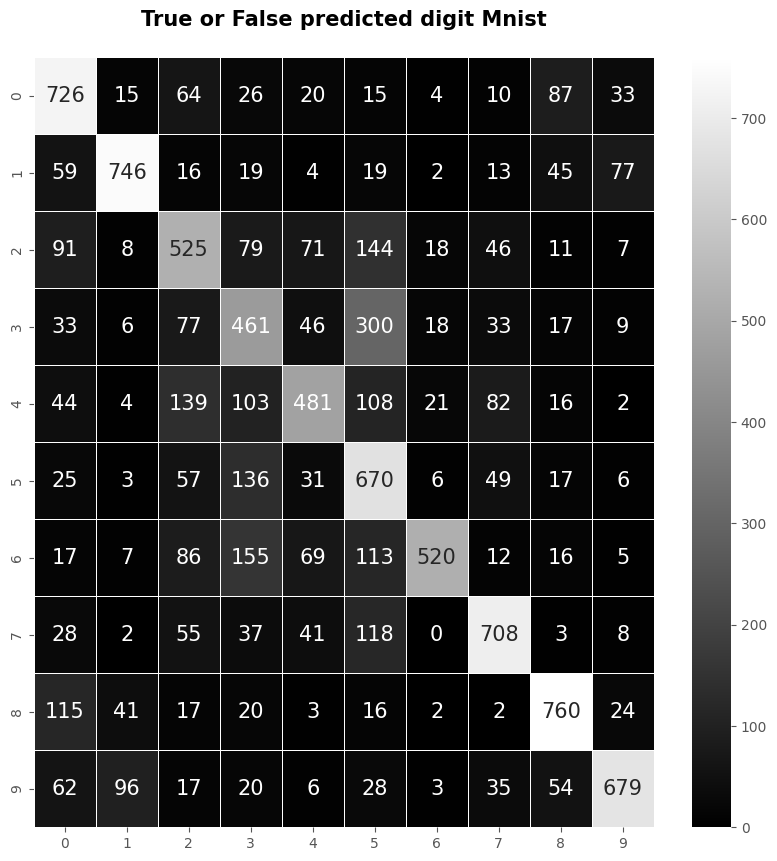

In [24]:
#Confusion matrix for digit mnist
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
con_mat = confusion_matrix(y_test,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit Mnist\n', fontweight='bold',fontsize=15)
plt.show()

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predicts))

              precision    recall  f1-score   support

           0       0.60      0.73      0.66      1000
           1       0.80      0.75      0.77      1000
           2       0.50      0.53      0.51      1000
           3       0.44      0.46      0.45      1000
           4       0.62      0.48      0.54      1000
           5       0.44      0.67      0.53      1000
           6       0.88      0.52      0.65      1000
           7       0.72      0.71      0.71      1000
           8       0.74      0.76      0.75      1000
           9       0.80      0.68      0.73      1000

    accuracy                           0.63     10000
   macro avg       0.65      0.63      0.63     10000
weighted avg       0.65      0.63      0.63     10000



In [31]:

img = x_test[image_index]

img = img.reshape(1, 32, 32, 3)   

pred = model.predict(img)

predicted_class = np.argmax(pred, axis=1)[0]

print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1
